In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.facecolor': 'white',
})


In [2]:
df = pd.read_csv('parking_snapshots.csv')
print(f"Shape: {df.shape}")
print(f"Date range (raw): {df['collected_at'].min()} → {df['collected_at'].max()}")
print(f"Unique lots: {sorted(df['lot_name'].unique())}")
print(f"Nulls:\n{df.isnull().sum()}")
df.head()


Shape: (17308, 4)
Date range (raw): 2026-01-22 16:08:19.167993+00 → 2026-02-12 03:01:48.817173+00
Unique lots: ['big_springs_1', 'big_springs_2', 'lot_24', 'lot_26', 'lot_30', 'lot_32', 'lot_50', 'lot_6']
Nulls:
collected_at     0
lot_name         0
free_spaces      0
occupancy_pct    0
dtype: int64


,collected_at,lot_name,free_spaces,occupancy_pct
0,2026-02-12 03:01:48.817173+00,lot_50,305,26.15
1,2026-02-12 03:01:48.717543+00,lot_32,212,17.83
2,2026-02-12 03:01:48.617573+00,lot_30,1395,34.90
3,2026-02-12 03:01:48.517156+00,lot_26,357,18.12
4,2026-02-12 03:01:48.417105+00,lot_24,144,64.53


## Data Conversions
- Convert `collected_at` from UTC → PST (America/Los_Angeles)
- Extract `hour`, `day_of_week`, `date` for grouping
- Compute `total_spaces` from `free_spaces` and `occupancy_pct`

In [3]:
# --- Convert UTC → PST ---
df['collected_at'] = pd.to_datetime(df['collected_at'], utc=True)
df['collected_at_pst'] = df['collected_at'].dt.tz_convert('America/Los_Angeles')

# --- Derived columns ---
df['hour'] = df['collected_at_pst'].dt.hour
df['day_of_week'] = df['collected_at_pst'].dt.day_name()
df['date'] = df['collected_at_pst'].dt.date
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])

# Total capacity per lot (back-calculated)
# total = free_spaces / (1 - occupancy_pct/100) when occupancy < 100
mask = df['occupancy_pct'] < 100
df.loc[mask, 'total_spaces'] = (df.loc[mask, 'free_spaces'] / (1 - df.loc[mask, 'occupancy_pct'] / 100)).round().astype(int)

# Fill the 100% occupancy rows using each lot's known capacity
lot_capacity = df.dropna(subset=['total_spaces']).groupby('lot_name')['total_spaces'].median().round().astype(int)
print("Estimated total capacity per lot:")
print(lot_capacity.to_string())

df['total_spaces'] = df.apply(
    lambda r: lot_capacity.get(r['lot_name'], np.nan) if pd.isna(r['total_spaces']) else r['total_spaces'], axis=1
)

print(f"\nPST date range: {df['collected_at_pst'].min()} → {df['collected_at_pst'].max()}")
print(f"Snapshots per lot:\n{df.groupby('lot_name').size()}")
df[['lot_name', 'collected_at_pst', 'free_spaces', 'occupancy_pct', 'total_spaces', 'hour', 'day_of_week']].head(10)


Estimated total capacity per lot:
lot_name
big_springs_1     490
big_springs_2    1058
lot_24            406
lot_26            436
lot_30           2143
lot_32            258
lot_50            413
lot_6             387

PST date range: 2026-01-22 08:08:19.167993-08:00 → 2026-02-11 19:01:48.817173-08:00
Snapshots per lot:
lot_name
big_springs_1    2327
big_springs_2    1019
lot_24           2327
lot_26           2327
lot_30           2327
lot_32           2327
lot_50           2327
lot_6            2327
dtype: int64


,lot_name,collected_at_pst,free_spaces,occupancy_pct,total_spaces,hour,day_of_week
0,lot_50,2026-02-11 19:01:48.817173-08:00,305,26.15,413.0,19,Wednesday
1,lot_32,2026-02-11 19:01:48.717543-08:00,212,17.83,258.0,19,Wednesday
2,lot_30,2026-02-11 19:01:48.617573-08:00,1395,34.90,2143.0,19,Wednesday
3,lot_26,2026-02-11 19:01:48.517156-08:00,357,18.12,436.0,19,Wednesday
4,lot_24,2026-02-11 19:01:48.417105-08:00,144,64.53,406.0,19,Wednesday
5,lot_6,2026-02-11 19:01:48.316341-08:00,216,44.19,387.0,19,Wednesday
6,big_springs_1,2026-02-11 19:01:48.092637-08:00,195,60.20,490.0,19,Wednesday
7,lot_50,2026-02-11 18:02:22.964373-08:00,271,34.38,413.0,18,Wednesday
8,lot_32,2026-02-11 18:02:22.865495-08:00,168,34.88,258.0,18,Wednesday
9,lot_30,2026-02-11 18:02:22.764718-08:00,1034,51.75,2143.0,18,Wednesday


## 1. Occupancy Distribution by Lot

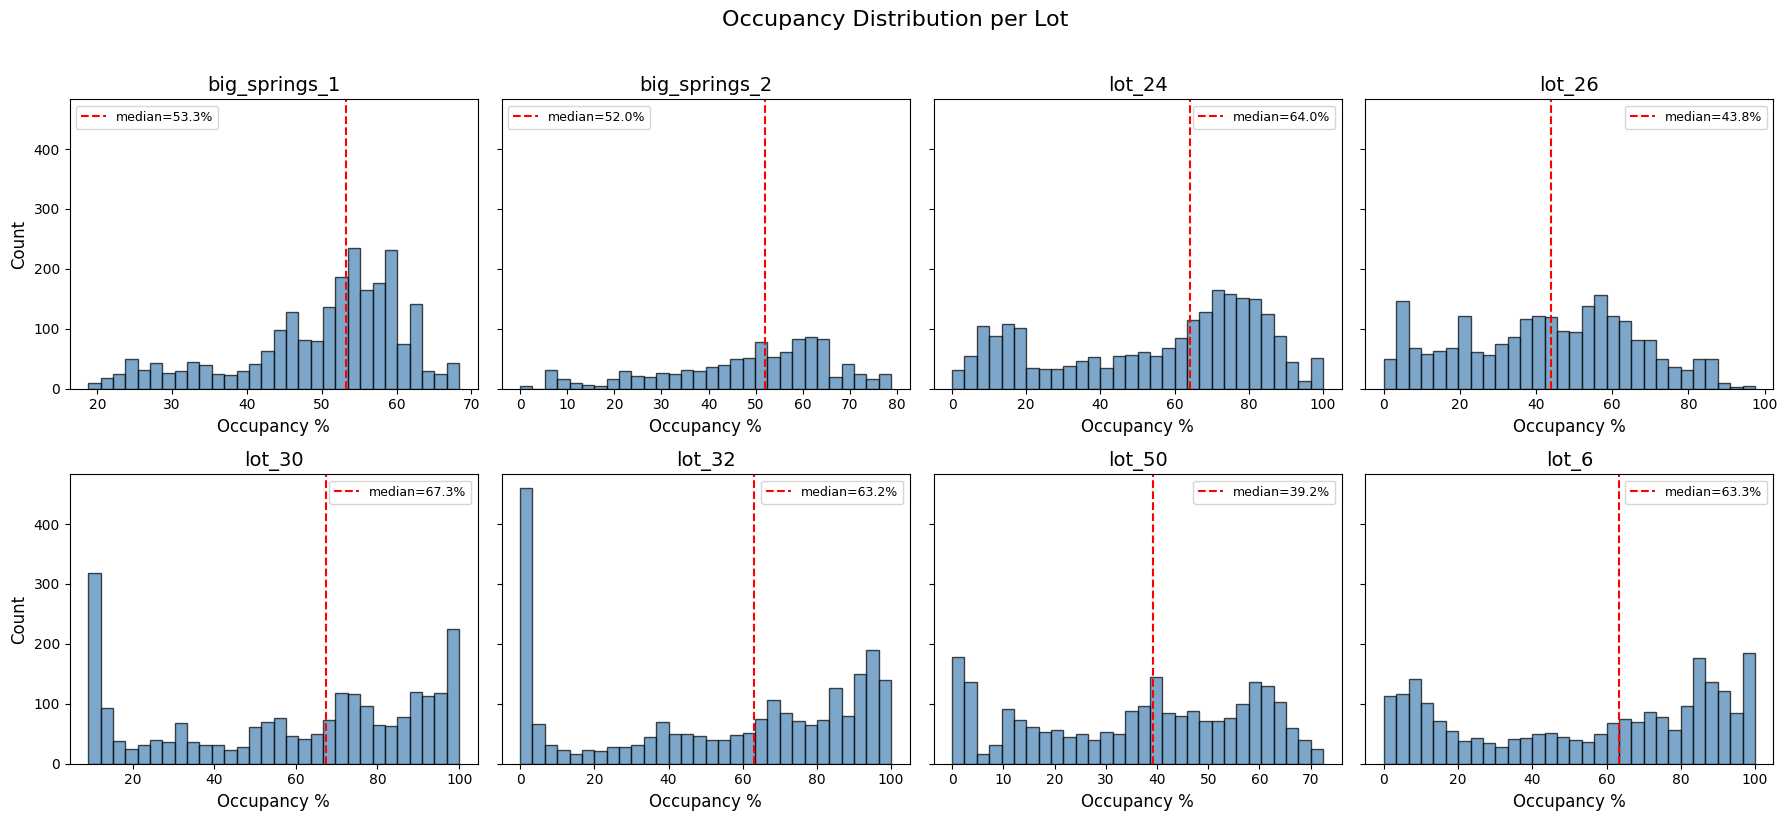

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
lots = sorted(df['lot_name'].unique())

for ax, lot in zip(axes.flat, lots):
    data = df[df['lot_name'] == lot]['occupancy_pct']
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(data.median(), color='red', linestyle='--', label=f'median={data.median():.1f}%')
    ax.set_title(lot)
    ax.set_xlabel('Occupancy %')
    ax.legend(fontsize=9)

axes[0, 0].set_ylabel('Count')
axes[1, 0].set_ylabel('Count')
fig.suptitle('Occupancy Distribution per Lot', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


## 2. Average Occupancy by Hour of Day (Weekday vs Weekend)

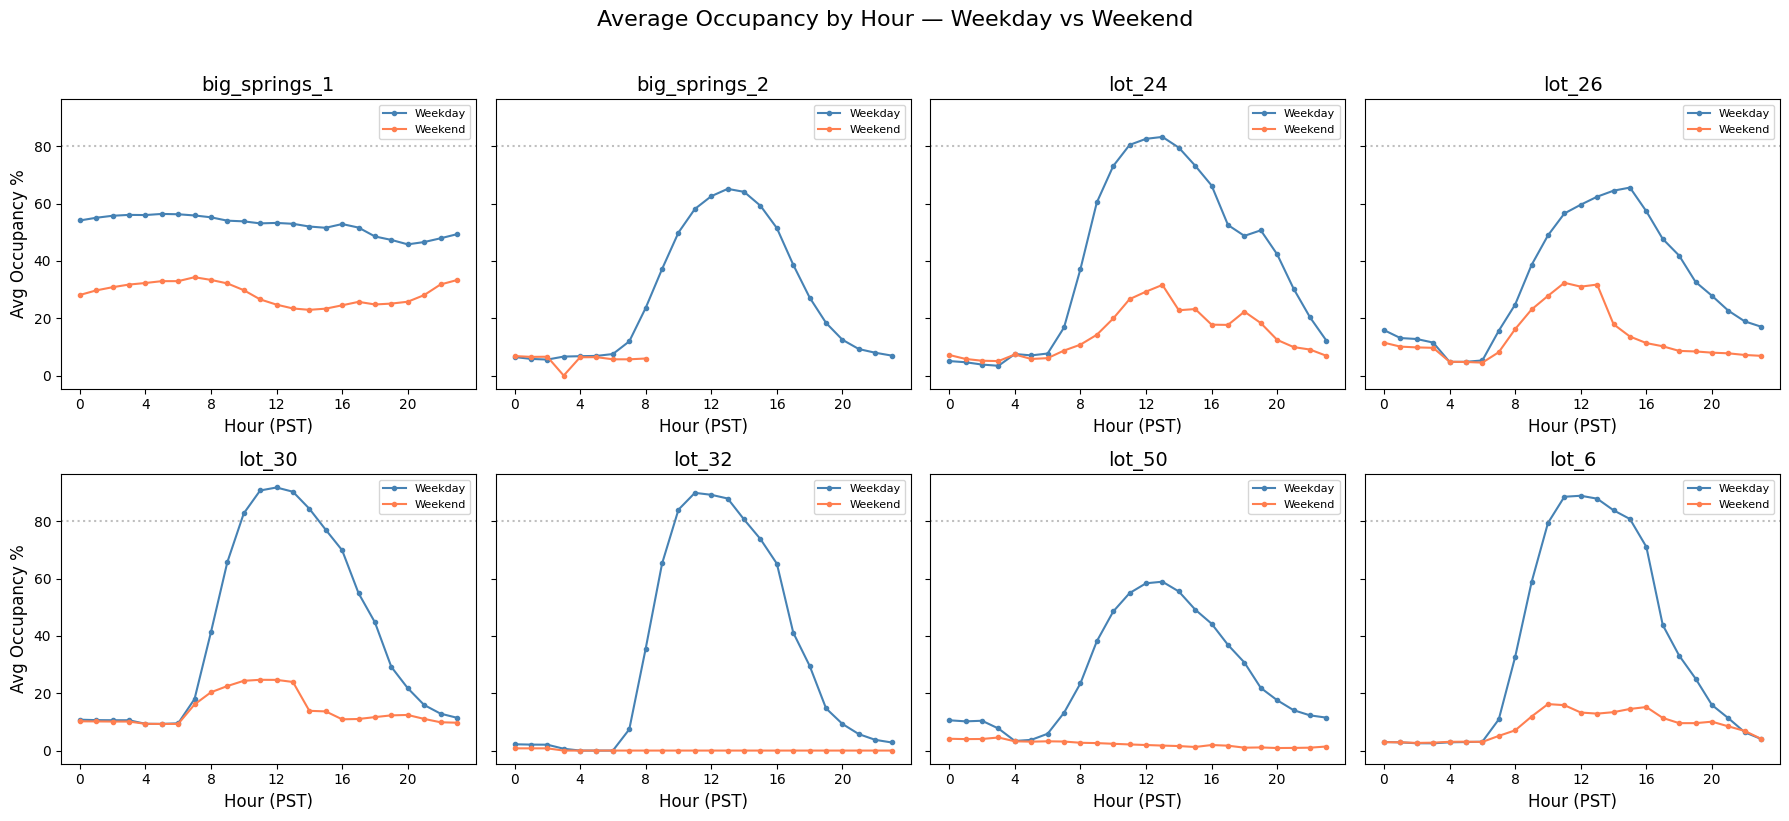

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)

for ax, lot in zip(axes.flat, lots):
    for is_wknd, label, color in [(False, 'Weekday', 'steelblue'), (True, 'Weekend', 'coral')]:
        subset = df[(df['lot_name'] == lot) & (df['is_weekend'] == is_wknd)]
        hourly = subset.groupby('hour')['occupancy_pct'].mean()
        ax.plot(hourly.index, hourly.values, marker='o', markersize=3, label=label, color=color)
    ax.set_title(lot)
    ax.set_xlabel('Hour (PST)')
    ax.set_xticks(range(0, 24, 4))
    ax.legend(fontsize=8)
    ax.axhline(80, color='gray', linestyle=':', alpha=0.5)

axes[0, 0].set_ylabel('Avg Occupancy %')
axes[1, 0].set_ylabel('Avg Occupancy %')
fig.suptitle('Average Occupancy by Hour — Weekday vs Weekend', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


## 3. Heatmap — Average Occupancy by Day of Week × Hour

/var/folders/zn/fdymfjf11cb1lvkx8_s0wqwh0000gn/T/ipykernel_36706/2713904860.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


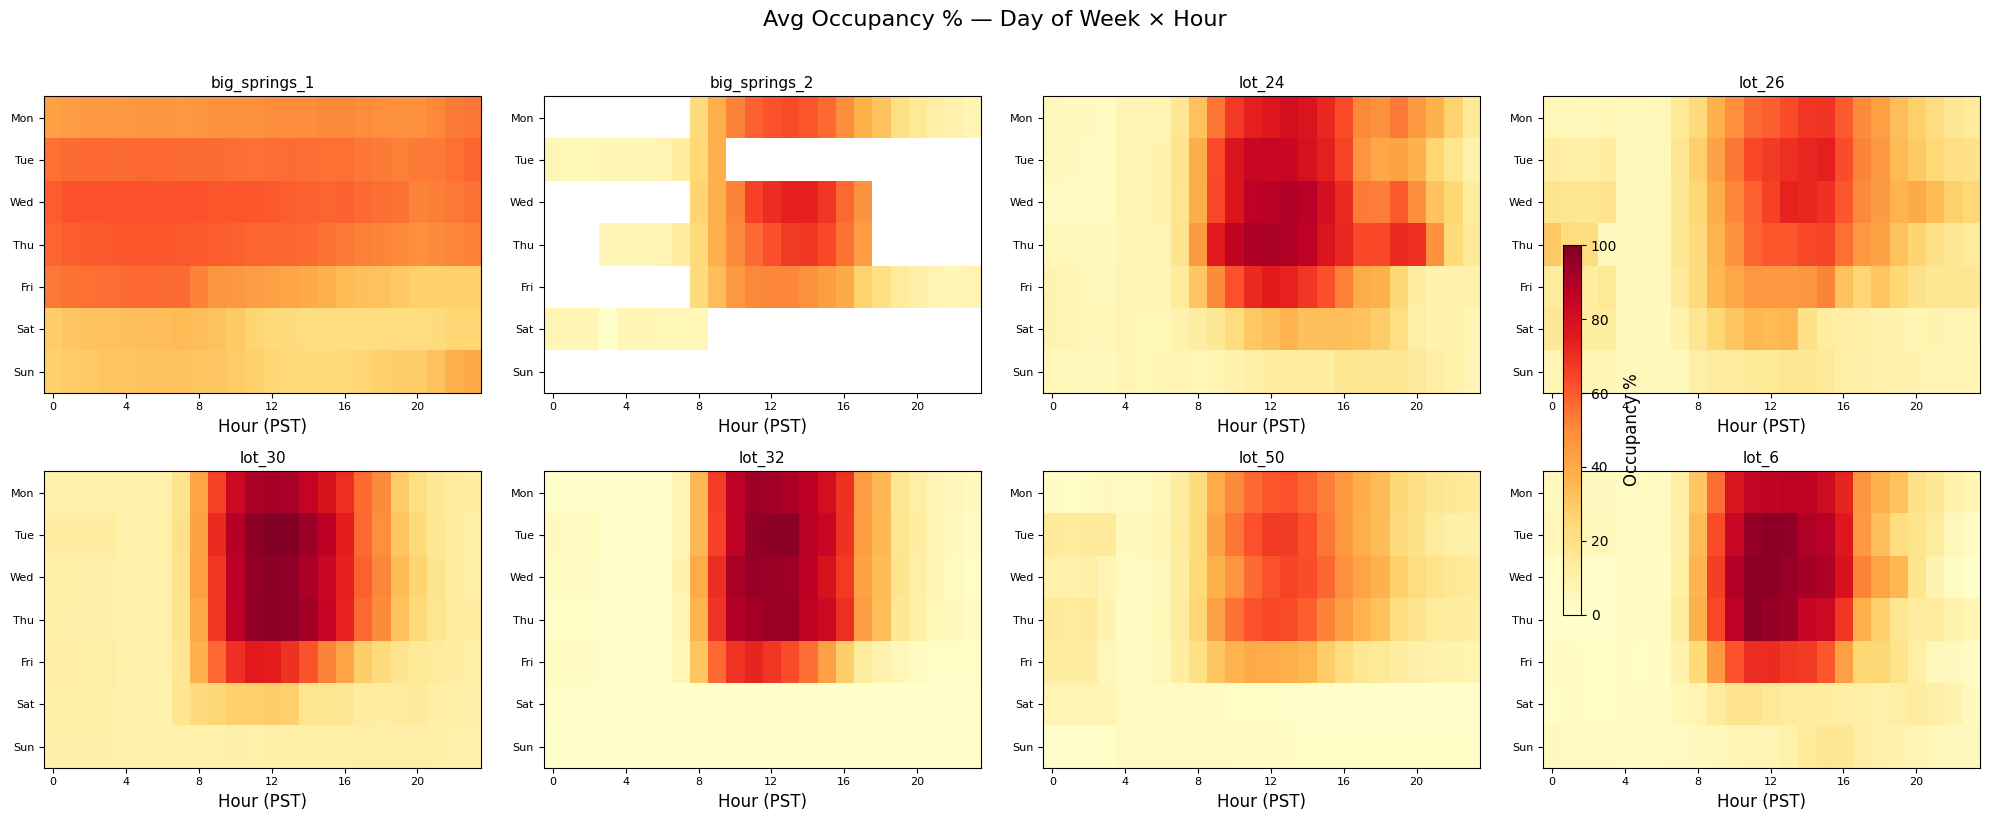

In [6]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for ax, lot in zip(axes.flat, lots):
    pivot = df[df['lot_name'] == lot].pivot_table(
        values='occupancy_pct', index='day_of_week', columns='hour', aggfunc='mean'
    ).reindex(day_order)
    im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=100)
    ax.set_title(lot, fontsize=11)
    ax.set_yticks(range(7))
    ax.set_yticklabels([d[:3] for d in day_order], fontsize=8)
    ax.set_xticks(range(0, 24, 4))
    ax.set_xticklabels(range(0, 24, 4), fontsize=8)
    ax.set_xlabel('Hour (PST)')

fig.suptitle('Avg Occupancy % — Day of Week × Hour', fontsize=16, y=1.02)
fig.colorbar(im, ax=axes, shrink=0.6, label='Occupancy %')
plt.tight_layout()
plt.show()


## 4. Time Series — Occupancy Over the Full Collection Period

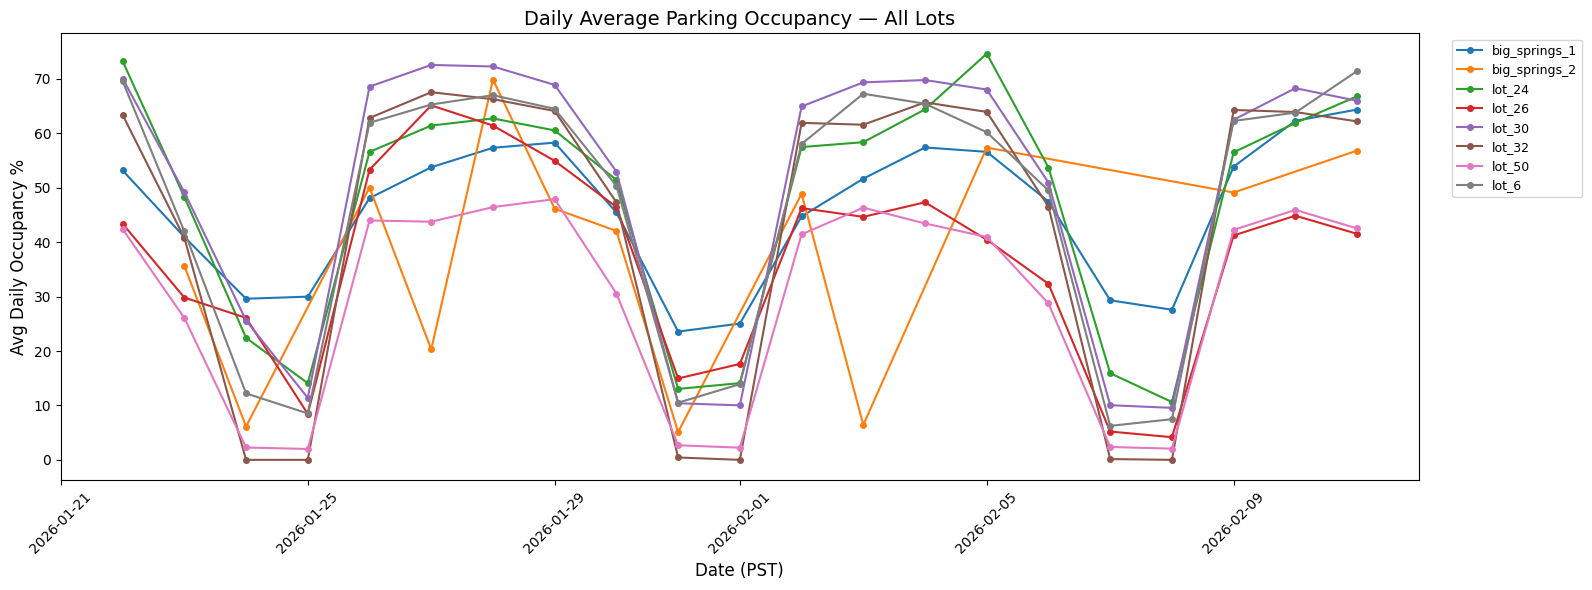

In [7]:
# Daily average instead of raw snapshots to avoid overplotting
daily_avg = df.groupby(['date', 'lot_name'])['occupancy_pct'].mean().reset_index()

fig, ax = plt.subplots(figsize=(16, 6))
for lot in lots:
    subset = daily_avg[daily_avg['lot_name'] == lot].sort_values('date')
    ax.plot(subset['date'], subset['occupancy_pct'], marker='o', markersize=4, label=lot, linewidth=1.5)

ax.set_ylabel('Avg Daily Occupancy %')
ax.set_xlabel('Date (PST)')
ax.set_title('Daily Average Parking Occupancy — All Lots')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Peak Occupancy — How Often Does Each Lot Hit 90%+?

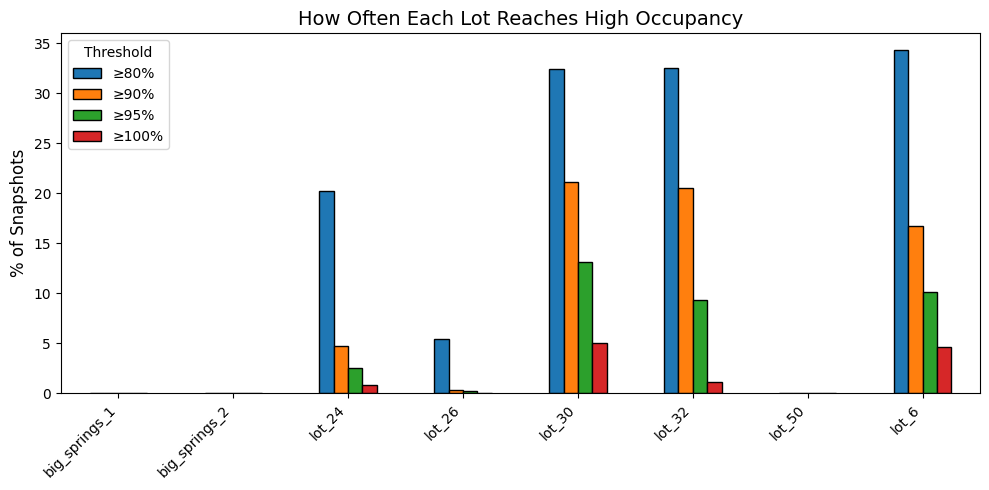

threshold      ≥80%  ≥90%  ≥95%  ≥100%
lot                                   
big_springs_1   0.0   0.0   0.0    0.0
big_springs_2   0.0   0.0   0.0    0.0
lot_24         20.2   4.7   2.5    0.8
lot_26          5.4   0.3   0.2    0.0
lot_30         32.4  21.1  13.1    5.0
lot_32         32.5  20.5   9.3    1.1
lot_50          0.0   0.0   0.0    0.0
lot_6          34.3  16.7  10.1    4.6


In [8]:
thresholds = [80, 90, 95, 100]
records = []
for lot in lots:
    sub = df[df['lot_name'] == lot]
    n = len(sub)
    for t in thresholds:
        count = (sub['occupancy_pct'] >= t).sum()
        records.append({'lot': lot, f'threshold': f'≥{t}%', 'count': count, 'pct_of_snapshots': round(count / n * 100, 1)})

peak_df = pd.DataFrame(records).pivot_table(index='lot', columns='threshold', values='pct_of_snapshots')
peak_df = peak_df[['≥80%', '≥90%', '≥95%', '≥100%']]

fig, ax = plt.subplots(figsize=(10, 5))
peak_df.plot(kind='bar', ax=ax, edgecolor='black')
ax.set_ylabel('% of Snapshots')
ax.set_title('How Often Each Lot Reaches High Occupancy')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Threshold')
plt.tight_layout()
plt.show()

print(peak_df.to_string())


## 6. Sampling Frequency — Snapshots per Day per Lot

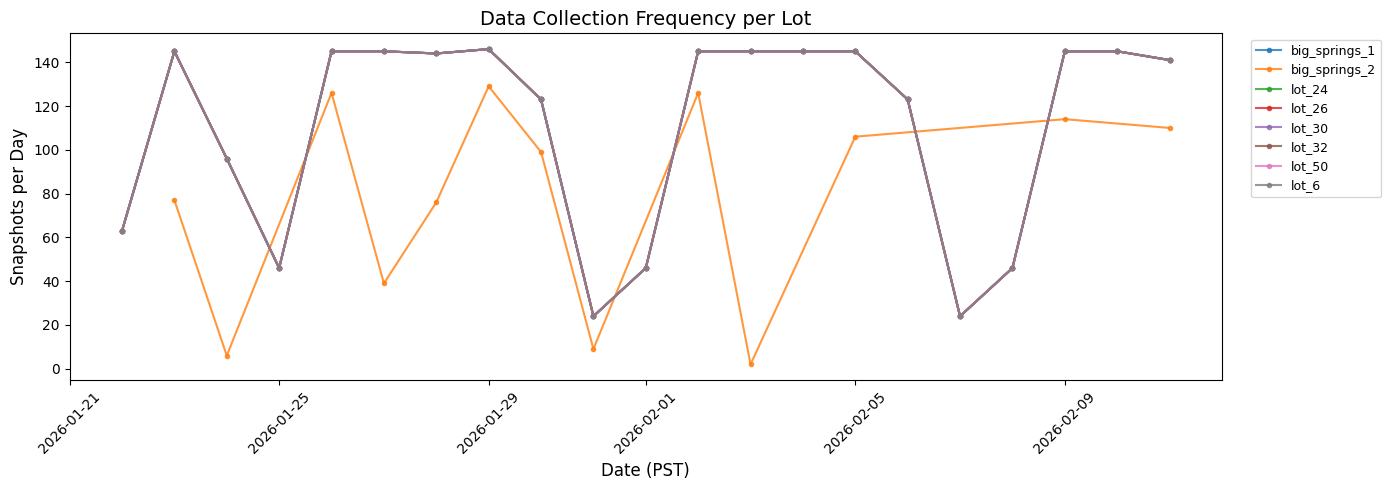

Snapshots per day stats (across all lots):
               count   mean   std   min   25%    50%    75%    max
lot_name                                                          
big_springs_1   21.0  110.8  47.0  24.0  63.0  144.0  145.0  146.0
big_springs_2   13.0   78.4  48.3   2.0  39.0   99.0  114.0  129.0
lot_24          21.0  110.8  47.0  24.0  63.0  144.0  145.0  146.0
lot_26          21.0  110.8  47.0  24.0  63.0  144.0  145.0  146.0
lot_30          21.0  110.8  47.0  24.0  63.0  144.0  145.0  146.0
lot_32          21.0  110.8  47.0  24.0  63.0  144.0  145.0  146.0
lot_50          21.0  110.8  47.0  24.0  63.0  144.0  145.0  146.0
lot_6           21.0  110.8  47.0  24.0  63.0  144.0  145.0  146.0


In [9]:
snap_per_day = df.groupby(['date', 'lot_name']).size().reset_index(name='snapshots')

fig, ax = plt.subplots(figsize=(14, 5))
for lot in lots:
    sub = snap_per_day[snap_per_day['lot_name'] == lot]
    ax.plot(sub['date'], sub['snapshots'], marker='o', markersize=3, label=lot, alpha=0.8)

ax.set_ylabel('Snapshots per Day')
ax.set_xlabel('Date (PST)')
ax.set_title('Data Collection Frequency per Lot')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Snapshots per day stats (across all lots):")
print(snap_per_day.groupby('lot_name')['snapshots'].describe().round(1).to_string())


## 7. Summary Statistics per Lot

In [10]:
summary = df.groupby('lot_name').agg(
    capacity=('total_spaces', 'median'),
    avg_occupancy=('occupancy_pct', 'mean'),
    median_occupancy=('occupancy_pct', 'median'),
    std_occupancy=('occupancy_pct', 'std'),
    min_occupancy=('occupancy_pct', 'min'),
    max_occupancy=('occupancy_pct', 'max'),
    avg_free=('free_spaces', 'mean'),
    num_snapshots=('occupancy_pct', 'count'),
).round(1)

summary


,capacity,avg_occupancy,median_occupancy,std_occupancy,min_occupancy,max_occupancy,avg_free,num_snapshots
lot_name,,,,,,,,
big_springs_1,490.0,50.1,53.3,10.9,18.8,68.4,244.5,2327
big_springs_2,1058.0,48.5,52.0,17.7,0.0,78.7,544.5,1019
lot_24,406.0,54.9,64.0,27.9,0.0,100.0,183.2,2327
lot_26,436.0,42.7,43.8,23.0,0.0,97.5,249.7,2327
lot_30,2143.0,59.0,67.3,31.2,9.2,100.0,878.0,2327
lot_32,258.0,53.0,63.2,35.8,0.0,100.0,121.2,2327
lot_50,413.0,36.3,39.2,21.3,0.0,72.4,263.0,2327
lot_6,387.0,55.0,63.3,33.6,0.0,100.0,174.2,2327
